In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/students_Intellipaat.csv')

In [ ]:
df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8,4.2,3,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   object 
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   object 
 4   Social_Hours_Per_Day             2000 non-null   object 
 5   Physical_Activity_Hours_Per_Day  2000 non-null   object 
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 125.1+ KB


Perform a comprehensive data preprocessing workflow on the given dataset, students_Intellipaat.csv, ensuring the removal of any extraneous symbols, special characters, or inconsistencies. After refining the dataset, analyze student sleep patterns and identify student IDs where sleep duration exceeds the overall average sleep hours, yet the reported stress levels remain high.

In [ ]:
#checking and replacing the unwanted values with np.nan
for i in df:
  print(df[i].unique())
  df[i] = df[i].replace('?', np.nan)
  print(df[i].unique())


[   1    2    3 ... 1998 1999 2000]
[   1    2    3 ... 1998 1999 2000]
['6.9' '5.3' '5.1' '6.5' '8.1' '2.4' '8' '8.4' '5.2' '7.7' '9.7' '6.4' '5'
 '8.9' '6.7' '8.6' '8.8' '7.6' '6.6' '7.1' '9.6' '9' '6.1' '6.8' '9.9'
 '6.2' '5.5' '8.2' '9.1' '8.3' '9.5' '7.9' '9.3' '9.4' '7.3' '5.8' '7.4'
 '5.9' '5.4' '8.7' '8.5' '5.6' '9.8' '10' '7.8' '6' '6.3' '7.2' '5.7'
 '9.2' '7' '7.5' '?']
['6.9' '5.3' '5.1' '6.5' '8.1' '2.4' '8' '8.4' '5.2' '7.7' '9.7' '6.4' '5'
 '8.9' '6.7' '8.6' '8.8' '7.6' '6.6' '7.1' '9.6' '9' '6.1' '6.8' '9.9'
 '6.2' '5.5' '8.2' '9.1' '8.3' '9.5' '7.9' '9.3' '9.4' '7.3' '5.8' '7.4'
 '5.9' '5.4' '8.7' '8.5' '5.6' '9.8' '10' '7.8' '6' '6.3' '7.2' '5.7'
 '9.2' '7' '7.5' nan]
[3.8 3.5 3.9 2.1 0.6 0.7 1.8 3.6 1.1 2.2 3.3 0.3 2.6 1.7 2.  3.  3.2 1.3
 0.1 1.  2.9 2.4 0.9 3.4 1.5 2.5 3.7 2.8 1.2 1.4 0.5 0.4 2.3 2.7 3.1 1.9
 4.  1.6 0.  0.2 0.8]
[3.8 3.5 3.9 2.1 0.6 0.7 1.8 3.6 1.1 2.2 3.3 0.3 2.6 1.7 2.  3.  3.2 1.3
 0.1 1.  2.9 2.4 0.9 3.4 1.5 2.5 3.7 2.8 1.2 1.4 0.5 0.4 2.3 2.7 

In [ ]:
df.isnull().sum()

,0
Student_ID,0
Study_Hours_Per_Day,1
Extracurricular_Hours_Per_Day,0
Sleep_Hours_Per_Day,13
Social_Hours_Per_Day,6
Physical_Activity_Hours_Per_Day,3
GPA,0
Stress_Level,1


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['Student_ID', 'Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day',
       'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day',
       'Physical_Activity_Hours_Per_Day', 'GPA', 'Stress_Level'],
      dtype='object')

In [ ]:
col = df[['Student_ID', 'Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day','Sleep_Hours_Per_Day', 'Social_Hours_Per_Day','Physical_Activity_Hours_Per_Day', 'GPA']]

In [ ]:
df.isnull().sum().sum()/df.shape[0] * 100

np.float64(1.2)

In [ ]:
df.dropna(inplace = True)

In [ ]:
for i in col.columns: #datatype changed ro numeric
  if df[i].dtype == 'object':
    df[i] = pd.to_numeric(df[i], errors = 'coerce')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1976 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       1976 non-null   int64  
 1   Study_Hours_Per_Day              1976 non-null   float64
 2   Extracurricular_Hours_Per_Day    1976 non-null   float64
 3   Sleep_Hours_Per_Day              1976 non-null   float64
 4   Social_Hours_Per_Day             1976 non-null   float64
 5   Physical_Activity_Hours_Per_Day  1976 non-null   float64
 6   GPA                              1976 non-null   float64
 7   Stress_Level                     1976 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 138.9+ KB


In [ ]:
df.Stress_Level.value_counts()

,count
Stress_Level,
High,1013
Moderate,668
Low,295


In [ ]:
sleep_avg= df['Sleep_Hours_Per_Day'].mean()
print(f'average sleep of student : {sleep_avg:.2f}')

average sleep of student : 7.50


In [ ]:
deep_sleep = df[(df['Sleep_Hours_Per_Day'] > sleep_avg) & (df['Stress_Level'] == 'High')]
print(f'Total {deep_sleep['Student_ID'].shape[0]} students sleep longer than average sleep ({sleep_avg:.2f}) and having high stress level')

Total 400 students sleep longer than average sleep (7.50) and having high stress level


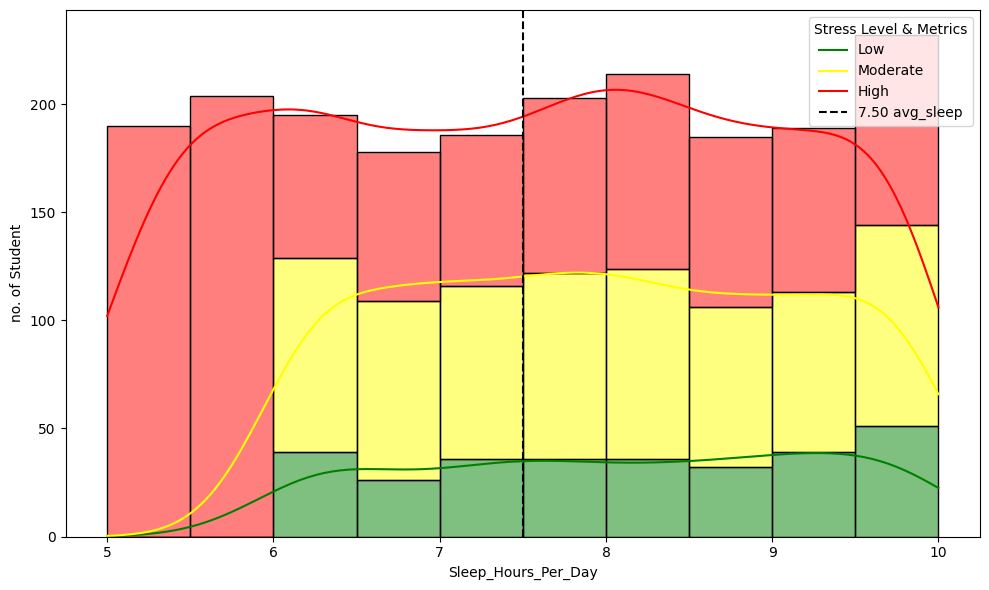

In [ ]:
plt.figure(figsize = (10,6))
stress_color = {'High' : 'Red',
                'Moderate' : 'Yellow',
                'Low' : 'Green'}
sns.histplot(data = df, x= 'Sleep_Hours_Per_Day',bins= 'auto', hue='Stress_Level', multiple='stack',hue_order = ['High', 'Moderate', 'Low'], kde=True, palette = stress_color, binwidth=0.5, binrange= (5,10))
plt.axvline(df['Sleep_Hours_Per_Day'].mean(), linestyle = '--', color='black', label = f'{df['Sleep_Hours_Per_Day'].mean():.2f}')
plt.ylabel('no. of Student')
plt.legend(['Low','Moderate','High', f'{df['Sleep_Hours_Per_Day'].mean():.2f} avg_sleep'],title='Stress Level & Metrics')
plt.tight_layout()
plt.show()

2) A hypothesis has been made that the average daily hours allocated to extracurricular, social, and physical activities are equal. Utilizing the cleaned dataset, apply appropriate statistical tests to validate or refute this assumption with empirical evidence, ensuring the conclusion is data-driven rather than based on conjecture.

In [ ]:
h0 = 'average daily hours allocated to extracurricular, social, and physical activities are equal'
H1 = "no it's not equal"

will use ANOVA test -> comparing average for more three classes

In [ ]:
from scipy.stats.stats import f_oneway

In [ ]:
extra_hours = df[[ 'Extracurricular_Hours_Per_Day', 'Social_Hours_Per_Day','Physical_Activity_Hours_Per_Day']]
for i in extra_hours:
  avg_hours= extra_hours[i].mean()
  print(f' Average hours for {i} are {avg_hours:.2f}')

 Average hours for Extracurricular_Hours_Per_Day are 1.99
 Average hours for Social_Hours_Per_Day are 2.70
 Average hours for Physical_Activity_Hours_Per_Day are 4.33


In [ ]:
f_stat, p_value = f_oneway(extra_hours['Extracurricular_Hours_Per_Day'],
                           extra_hours['Social_Hours_Per_Day'],
                           extra_hours['Physical_Activity_Hours_Per_Day'])

In [ ]:
print(f"  - P-Value:     {p_value}")

  - P-Value:     1.73736960214706e-310


p-value is greater than significance level 0.05 which means we reject the null hypothesis

 It is hypothesized that students’ stress levels are associated with their sleep duration, specifically whether they sleep less than or more than the average sleep hours. To validate this assumption, use the above-cleaned data and form data for below or above-average

sleep hours and collect the statistical evidence for this assumption.

In [ ]:
df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [ ]:
from scipy.stats import chi2_contingency

# Hypothesis for Chi-square Test of Independence:
# H0: Stress_Level and sleep_group (based on Sleep_Hours_Per_Day) are independent.
# H1: Stress_Level and sleep_group (based on Sleep_Hours_Per_Day) are not independent.

# Corrected sleep_group to be based on 'Sleep_Hours_Per_Day' as per the problem statement
df['sleep_group'] = np.where(df['Sleep_Hours_Per_Day'] > sleep_avg, 'Above_average', 'Below_average')

# Create a contingency table
contingency_table = pd.crosstab(df['sleep_group'], df['Stress_Level'])

# Perform the chi-square test of independence
chi2_stat, p_value, dof, expected_freq = chi2_contingency(contingency_table)

print(f"P-value: {p_value:.3f}")


P-value: 0.000


Conduct a comprehensive data cleaning process on the provided dataset, Amazon_Stocks_Intellipaat.csv, ensuring it is suitable for time series forecasting.

In [ ]:
df_2 = pd.read_csv('/content/Amazon_Stocks.csv')

In [ ]:
df_2.head()

,Date,Begining_price,Higest_price,Lowest_price,Closing_price,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,16906900


In [ ]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2018 non-null   object 
 1   Begining_price  2018 non-null   float64
 2   Higest_price    2018 non-null   float64
 3   Lowest_price    2018 non-null   float64
 4   Closing_price   2018 non-null   float64
 5   Volume          2018 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 94.7+ KB


In [ ]:
df_2['Date'] = pd.to_datetime(df_2['Date'], format = '%Y-%m-%d')

In [ ]:
df_2.isnull().sum()

,0
Date,0
Begining_price,0
Higest_price,0
Lowest_price,0
Closing_price,0
Volume,0


In [ ]:
df_2.sort_values(by = 'Date', ascending = False, inplace = True)
df_2.head()

,Date,Begining_price,Higest_price,Lowest_price,Closing_price,Volume
2017,2022-02-04,407.309998,412.769989,396.640015,410.170013,7782400
1008,2022-02-04,407.309998,412.769989,396.640015,410.170013,7782400
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,9905200
2016,2022-02-03,421.440002,429.260010,404.279999,405.600006,9905200
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,14346000


In [ ]:
print(f'min data {df_2.Date.min()}')
print(f'max date {df_2.Date.max()}')

min data 2018-02-05 00:00:00
max date 2022-02-04 00:00:00


In [ ]:
df_2.duplicated().sum()# for stockmarket duplicates are important

np.int64(1009)

In [ ]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2018 entries, 2017 to 1009
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            2018 non-null   datetime64[ns]
 1   Begining_price  2018 non-null   float64       
 2   Higest_price    2018 non-null   float64       
 3   Lowest_price    2018 non-null   float64       
 4   Closing_price   2018 non-null   float64       
 5   Volume          2018 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 110.4 KB


In [ ]:
df_2.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,2018,2020-02-05 07:30:58.870168576,2018-02-05 00:00:00,2019-02-06 00:00:00,2020-02-06 00:00:00,2021-02-05 00:00:00,2022-02-04 00:00:00,NaN
Begining_price,2018.0,419.059673,233.919998,331.48999,377.769989,509.130005,692.349976,108.510623
Higest_price,2018.0,425.320703,250.649994,336.299988,383.01001,515.630005,700.98999,109.235871
Lowest_price,2018.0,412.374044,231.229996,326.0,370.880005,502.529999,686.090027,107.529202
Closing_price,2018.0,419.000733,233.880005,331.619995,378.670013,509.079987,691.690002,108.263151
Volume,2018.0,7570685.034688,1144000.0,4091900.0,5934500.0,9322400.0,58904300.0,5464180.190284


In [ ]:
#outlier checking
for col in df_2.columns:
  if df_2[col].dtype != 'object':
    q1 = df_2[col].quantile(0.25)
    q3 = df_2[col].quantile(0.75)

    IQR = q3-q1

    upper_limit = q3 + (1.5*IQR)
    lower_limit = q1 - (1.5*IQR)

    outliers = df_2[(df_2[col]> upper_limit)| (df_2[col]<lower_limit)]

    print(f'number of outilers in {col} : {len(outliers)}')



number of outilers in Date : 0
number of outilers in Begining_price : 0
number of outilers in Higest_price : 0
number of outilers in Lowest_price : 0
number of outilers in Closing_price : 0
number of outilers in Volume : 114


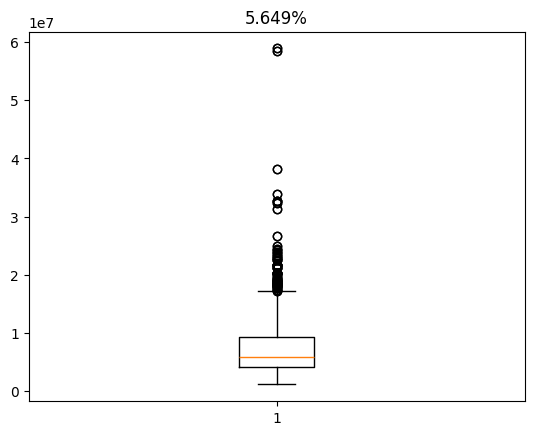

In [ ]:
    plt.boxplot(df_2['Volume'])
    plt.title(f'{len(outliers)/df_2.shape[0]*100:.3f}%')
    plt.show()

In [ ]:
from sklearn.preprocessing import PowerTransformer, RobustScaler

In [ ]:
for col in df_2.columns:
  if col != 'Date':
    print(f' skewness of {col} : {df_2[col].skew():.2f}')

 skewness of Begining_price : 0.46
 skewness of Higest_price : 0.46
 skewness of Lowest_price : 0.46
 skewness of Closing_price : 0.46
 skewness of Volume : 2.99


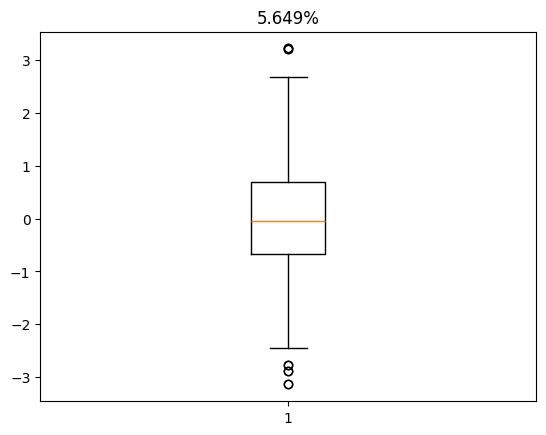

In [ ]:
#removing the skewness
PT = PowerTransformer(method = 'yeo-johnson')
df_2['Volume'] = PT.fit_transform(df_2[['Volume']])
plt.boxplot(df_2['Volume'])
plt.title(f'{len(outliers)/df_2.shape[0]*100:.3f}%')
plt.show()

In [ ]:
for col in df_2.columns:
  if col != 'Date':
    print(f' skewness of {col} : {df_2[col].skew():.2f}')

 skewness of Begining_price : 0.46
 skewness of Higest_price : 0.46
 skewness of Lowest_price : 0.46
 skewness of Closing_price : 0.46
 skewness of Volume : 0.01


data is normally distributed between 0.5 to -0.5

In [ ]:
df_2.columns

Index(['Date', 'Begining_price', 'Higest_price', 'Lowest_price',
       'Closing_price', 'Volume'],
      dtype='object')

In [ ]:
scaler = RobustScaler()
col = ['Begining_price', 'Higest_price', 'Lowest_price', 'Closing_price', 'Volume']
for i in col:
  df_2[i]= scaler.fit_transform(df_2[[i]])

In [ ]:
df_2.head()

,Date,Begining_price,Higest_price,Lowest_price,Closing_price,Volume
2017,2022-02-04,0.166291,0.165951,0.145924,0.177505,0.324522
1008,2022-02-04,0.166291,0.165951,0.145924,0.177505,0.324522
1007,2022-02-03,0.245834,0.257904,0.189203,0.151752,0.602753
2016,2022-02-03,0.245834,0.257904,0.189203,0.151752,0.602753
1006,2022-02-02,0.396758,0.384598,0.314961,0.286318,1.011568


In [ ]:
#outlier checking
for col in df_2.columns:
  if df_2[col].dtype != 'object':
    q1 = df_2[col].quantile(0.25)
    q3 = df_2[col].quantile(0.75)

    IQR = q3-q1

    upper_limit = q3 + (1.5*IQR)
    lower_limit = q1 - (1.5*IQR)

    outliers = df_2[(df_2[col]> upper_limit)| (df_2[col]<lower_limit)]

    print(f'number of outilers in {col} : {len(outliers)}')  # 10 outliers are not harmful as it help the ML to properly recognise the data sudden craches

number of outilers in Date : 0
number of outilers in Begining_price : 0
number of outilers in Higest_price : 0
number of outilers in Lowest_price : 0
number of outilers in Closing_price : 0
number of outilers in Volume : 10


Implement multiple time series forecasting models to predict the Closing Price of Amazon stock, assessing their performance using statistical evaluation metrics. Identify the most optimal model based on the lowest Root Mean Squared Error (RMSE), ensuring robustness and accuracy in predictive capability.

In [ ]:
clean_df_2 = df_2[['Date','Closing_price']].sort_values(by = 'Date', ascending = True).set_index('Date')
clean_df_2

,Closing_price
Date,
2018-02-05,-0.701060
2018-02-05,-0.701060
2018-02-06,-0.636482
2018-02-06,-0.636482
2018-02-07,-0.643018
...,...
2022-02-02,0.286318
2022-02-03,0.151752
2022-02-03,0.151752


<Axes: ylabel='Density'>

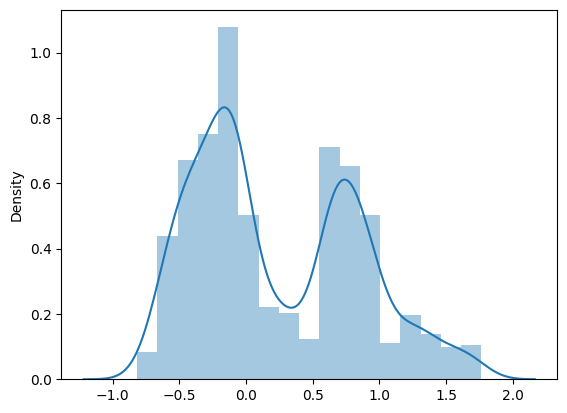

In [ ]:
sns.distplot(clean_df_2)

In [ ]:
# seasonal decompose to check the presence of the component of Time Series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [ ]:
avg_Closing_price = clean_df_2.groupby(clean_df_2.index)['Closing_price'].mean()
avg_Closing_price

,Closing_price
Date,
2018-02-05,-0.701060
2018-02-06,-0.636482
2018-02-07,-0.643018
2018-02-08,-0.724501
2018-02-09,-0.728051
...,...
2022-01-31,0.273132
2022-02-01,0.442128
2022-02-02,0.286318


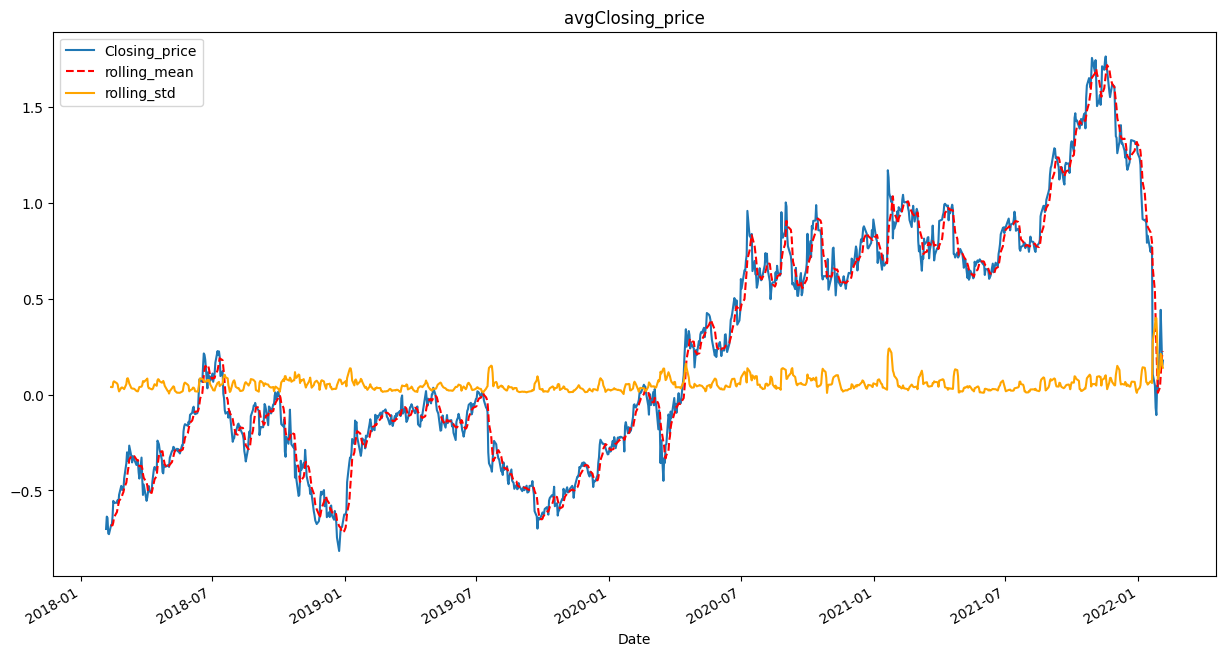

In [ ]:
avg_Closing_price.plot(figsize=(15,8),title = 'avgClosing_price')
closing_price_rolling_mean = avg_Closing_price.rolling(window = 6).mean()
closing_price_rolling_std = avg_Closing_price.rolling(window = 6).std()
plt.plot(closing_price_rolling_mean, linestyle = '--', color = 'red', label = 'rolling_mean')
plt.plot(closing_price_rolling_std, linestyle = '-', color = 'orange', label = 'rolling_std')
plt.legend()
plt.show()

In [ ]:
decompose = seasonal_decompose(avg_Closing_price)
print(decompose.plot())

ValueError: You must specify a period or x must be a pandas object with a PeriodIndex or a DatetimeIndex with a freq not set to None

In [ ]:
ad = adfuller(clean_df_2)
print(f' p-value {ad[1]:.2f}') # data is not stationay (pvalue >0.05)

hello
